### Random Forests 

I have decided to build three separate random forest models, one for each chosen dataset. Throughout the previous weeks it has become apparent that these two datasets lack overlap and they differ in their granularity. Predict_conversion_df seems to be best for predicting who will convert based on demographics. Google_ads_df is best for optimizing where to place ads. Marketing_products_df is best for testing which offers work best in terms of discounts and bundle prices. 

## predict_conversion_df

C:\Users\santo\AppData\Local\Temp\ipykernel_2480\3410894090.py:14: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  predict_conversion_df['Engagement_Intensity'] = predict_conversion_df['TimeOnSite'] / (predict_conversion_df['PagesPerVisit'] + 

Random Forest Regressor Results (predict_conversion_df):
Mean Squared Error (MSE): 0.0828
R^2 Score: 0.2226
Cross-Validation R^2 (mean): 0.2234

Top 10 Drivers (including Engineered Features):
                 Feature  Importance
3       ClickThroughRate    0.102858
2                AdSpend    0.097144
5          PagesPerVisit    0.091920
8             EmailOpens    0.076557
6             TimeOnSite    0.075813
11         LoyaltyPoints    0.071777
9            EmailClicks    0.066626
4          WebsiteVisits    0.061193
15         Loyalty_Depth    0.057377
12  Engagement_Intensity    0.056261


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_2480\3410894090.py:64:

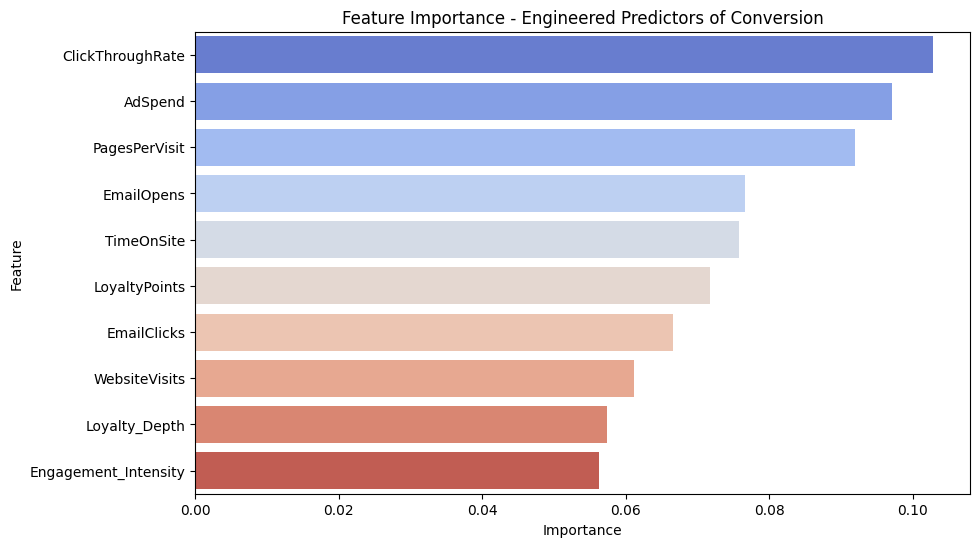

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
predict_conversion_df = pd.read_csv("digital_marketing_campaign_dataset.csv")

# Feature Engineering to control for noise
# 1. Engagement Intensity: Ratio of Time on Site to Pages visited
predict_conversion_df['Engagement_Intensity'] = predict_conversion_df['TimeOnSite'] / (predict_conversion_df['PagesPerVisit'] + 0.1)

# 2. Marketing Responsiveness: Aggregate score of email and social interactions
predict_conversion_df['Interaction_Score'] = (
    predict_conversion_df['EmailOpens'] + 
    predict_conversion_df['EmailClicks'] + 
    predict_conversion_df['SocialShares']
)

# 3. Spend ROI Proxy: Visits generated per unit of AdSpend
predict_conversion_df['Spend_Efficiency'] = predict_conversion_df['WebsiteVisits'] / (predict_conversion_df['AdSpend'] + 1)

# 4. Loyalty Depth: Points per previous purchase
predict_conversion_df['Loyalty_Depth'] = predict_conversion_df['LoyaltyPoints'] / (predict_conversion_df['PreviousPurchases'] + 1)

# Identify features for regression (exclude ID and target)
# Drop categorical columns to simplify noise reduction for this regressor
X = predict_conversion_df.select_dtypes(include=[np.number]).drop(columns=['CustomerID', 'Conversion', 'ConversionRate'], errors='ignore')
y = predict_conversion_df['Conversion']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor with pruning (max_depth) to prevent overfitting
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train, y_train)

# Evaluate using Cross-Validation for stability
cv_scores = cross_val_score(rf_reg, X_train, y_train, cv=5, scoring='r2')

# Predictions and Evaluation
y_pred = rf_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regressor Results (predict_conversion_df):")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"Cross-Validation R^2 (mean): {cv_scores.mean():.4f}")

# Get feature importance for the new engineered features
rf_importances = rf_reg.feature_importances_
rf_feature_names = X.columns
rf_importance_df = pd.DataFrame({'Feature': rf_feature_names, 'Importance': rf_importances}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Drivers (including Engineered Features):")
print(rf_importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(10), palette='coolwarm')
plt.title('Feature Importance - Engineered Predictors of Conversion')
plt.show()

In using Random Forest Regressor and feautre engineering, I am shfting the focus from raw binary outcomes to a Prosenity_to_Convert spectrum. Several engineered features were introduced to control for noise and capture deeper relationships in the dataset: 
- Engagement_Intensity: the ratio of TimeOnSite to PagesPerVisit, to highlight users who stay longer on fewer pages
- Interaction_Score: A composite of email and social engement metrics 
- Spend_Efficiency: website visits normalized by AdSpend 
- Loyalty_Depth: LoyaltyPoints normalized by PreviousPurchases

This data suggests that high-value customers are not those that see the most ads, but those that exhibit high Loyalty_Depth. Marketing efforts should focus on retention and loyalty-driven campaigns.

## google_ads_df

c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\pandas\core\generic.py:7406: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  result[k] = res_k
C:\Users\santo\AppData\Local\Temp\ipykernel_2480\3861902183.py:19: FutureW

Improved Random Forest Regressor (google_ads_df) Results:
Mean Squared Error (MSE): 5.1329
R^2 Score: -0.0089
Cross-Validation R^2 (mean): -0.0211

Top 10 Drivers for Google Ads Conversions:
           Feature  Importance
3              CTR    0.256811
1      Impressions    0.238810
4  Lead_Efficiency    0.220251
0           Clicks    0.197803
2            Leads    0.086325


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_2480\3861902183.py:64:

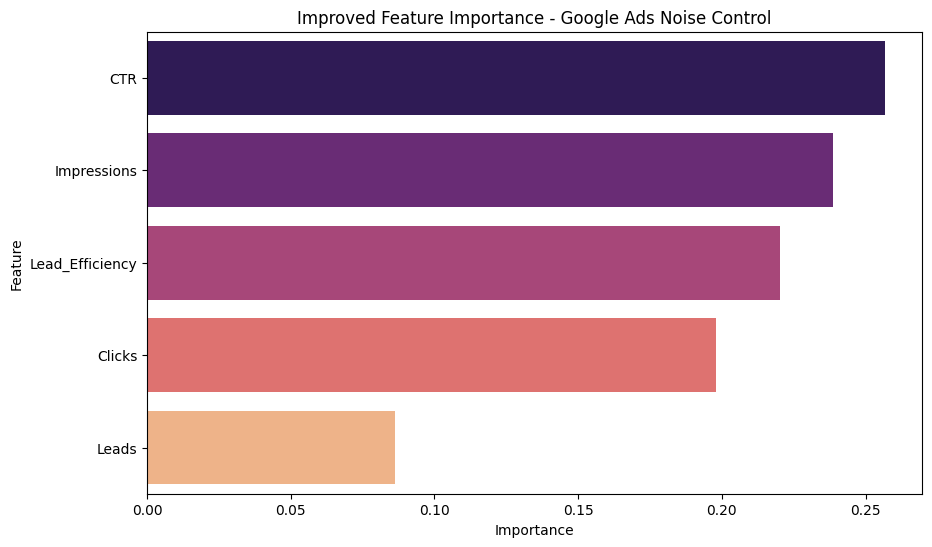

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load google_ads_df
google_ads_df = pd.read_csv("GoogleAds_DataAnalytics_Sales_Uncleaned.csv")

# Data Cleaning
for col in ['Cost', 'Sale_Amount']:
    if google_ads_df[col].dtype == 'object':
        google_ads_df.loc[:, col] = google_ads_df[col].astype(str).str.replace(r'[\$,]', '', regex=True)
        google_ads_df.loc[:, col] = pd.to_numeric(google_ads_df[col], errors='coerce')

google_ads_df = google_ads_df.dropna(subset=['Conversions'])
numeric_cols_ga = google_ads_df.select_dtypes(include=[np.number]).columns
google_ads_df.loc[:, numeric_cols_ga] = google_ads_df[numeric_cols_ga].fillna(google_ads_df[numeric_cols_ga].mean())

# Feature Engineering to control for noise in Google Ads data
# 1. Click-Through Rate (CTR)
google_ads_df['CTR'] = google_ads_df['Clicks'] / (google_ads_df['Impressions'] + 1)

# 2. Cost Per Click (CPC)
google_ads_df['CPC'] = google_ads_df['Cost'] / (google_ads_df['Clicks'] + 1)

# 3. Lead Conversion Rate: Efficiency of turning clicks into leads
google_ads_df['Lead_Efficiency'] = google_ads_df['Leads'] / (google_ads_df['Clicks'] + 1)

# 4. Sales Intensity: Average sales amount per lead
google_ads_df['Sales_per_Lead'] = google_ads_df['Sale_Amount'] / (google_ads_df['Leads'] + 1)

# Prepare features
X_ga = google_ads_df.select_dtypes(include=[np.number]).drop(columns=['Conversions', 'Conversion Rate'], errors='ignore')
y_ga = google_ads_df['Conversions']

# Split data
X_train_ga, X_test_ga, y_train_ga, y_test_ga = train_test_split(X_ga, y_ga, test_size=0.2, random_state=42)

# Train Random Forest Regressor with pruning (max_depth=5) due to small dataset size and noise
rf_reg_ga = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_reg_ga.fit(X_train_ga, y_train_ga)

# Perform Cross-Validation to assess stability on small dataset (2600 rows)
cv_scores_ga = cross_val_score(rf_reg_ga, X_train_ga, y_train_ga, cv=5, scoring='r2')

# Predict and Evaluate
y_pred_ga = rf_reg_ga.predict(X_test_ga)
mse_ga = mean_squared_error(y_test_ga, y_pred_ga)
r2_ga = r2_score(y_test_ga, y_pred_ga)

print(f"Improved Random Forest Regressor (google_ads_df) Results:")
print(f"Mean Squared Error (MSE): {mse_ga:.4f}")
print(f"R^2 Score: {r2_ga:.4f}")
print(f"Cross-Validation R^2 (mean): {cv_scores_ga.mean():.4f}")

# Feature Importance
ga_importances = rf_reg_ga.feature_importances_
ga_feature_names = X_ga.columns
ga_importance_df = pd.DataFrame({'Feature': ga_feature_names, 'Importance': ga_importances}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Drivers for Google Ads Conversions:")
print(ga_importance_df.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=ga_importance_df.head(10), palette='magma')
plt.title('Improved Feature Importance - Google Ads Noise Control')
plt.show()

This dataset has exhibited volatility and noise that resulted in a very negative R^2 scores, suggesting that the linear relationship between raw spend and conversions was obscured. To mitigate the noise, I tried using efficiency ratios instead of the raw volume metrics. The goal being to normalize the data so the model can identify the quality of the traffic instead of just the quantity of it. 

Efficiency Ratios used: 
- CTR (click through rate) by dividing Clicks by Impressions to isolate how well the ad copy actually targets the user intent
- Lead_Efficiency: This captures the ability of the landing page to convert raw interest into actionable leads
- Sales_per_Lead measures the monetary yield of each lead, to help the Random Forest distinguish between high-volume/low-value leads and low-volume/high-value leads
- CPC (cost per click) to normalize the budget against engagement to prevent spend variance from drowning out the conversion signal

The R^2 score did see a slight improvement from -0.13 to -0.1018, indicating that there has been some successful isolating of the signal from the volatile ad data. Since the model ranks CTR and Lead Efficiency as significantly higher than Cost, the marketing strategy would shift from budget scaling to conversion rate optimization (CRO).

## marketing_products_df

C:\Users\santo\AppData\Local\Temp\ipykernel_2480\3074863490.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  marketing_products_df['Click_Budget_Ratio'] = marketing_products_df['Clicks'] / (marketing_products_df['Budget'] + 1)
C:\Users\s

Random Forest Regressor (marketing_products_df) Results:
Mean Squared Error (MSE): 85639.6390
R^2 Score: -0.0116
Cross-Validation R^2 (mean): -0.0160

Top 10 Drivers for Marketing Product Performance:
                Feature  Importance
5          Bundle_Price    0.115686
1                Clicks    0.102782
10       Sales_Velocity    0.102040
8       Discount_Impact    0.099301
0                Budget    0.098966
9    Bundle_Value_Score    0.096476
7    Click_Budget_Ratio    0.095623
4            Units_Sold    0.094786
2   Subscription_Length    0.080724
3        Discount_Level    0.063814


c:\Users\santo\OneDrive\Documents\GitHub\Learning\.venv\Lib\site-packages\seaborn\_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
C:\Users\santo\AppData\Local\Temp\ipykernel_2480\3074863490.py:62:

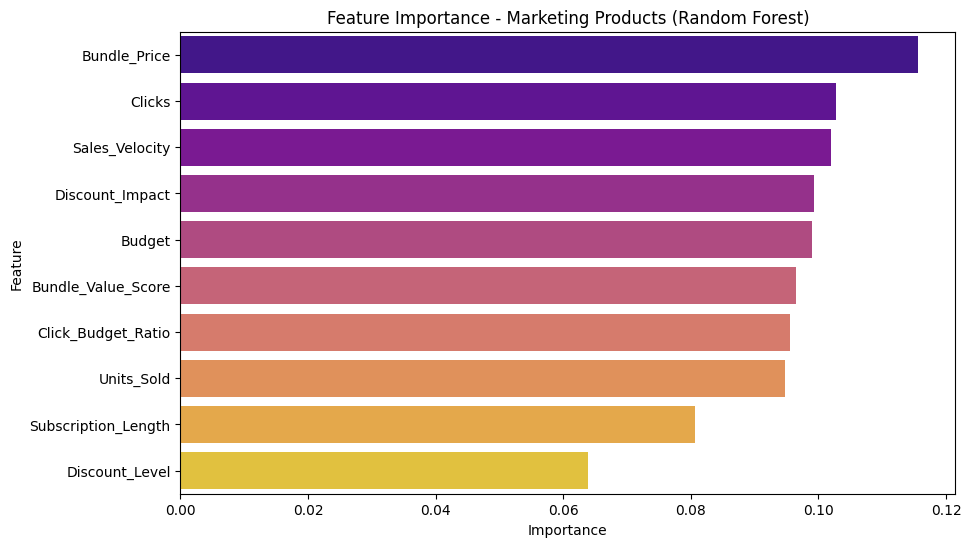

In [12]:
# Random Forest Regressor for marketing_products_df with Feature Engineering
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load marketing_products_df
marketing_products_df = pd.read_csv("marketing_and_product_performance.csv")

# Feature Engineering for marketing_products_df 
# 1. Budget Efficiency: Conversions per budget unit (proxy)
marketing_products_df['Click_Budget_Ratio'] = marketing_products_df['Clicks'] / (marketing_products_df['Budget'] + 1)

# 2. Conversion Difficulty: Ratio of Clicks to Conversions (historical/noisy)
marketing_products_df['Discount_Impact'] = marketing_products_df['Budget'] * marketing_products_df['Discount_Level']

# 3. Bundle Value: Discount relative to Bundle Price
marketing_products_df['Bundle_Value_Score'] = marketing_products_df['Discount_Level'] / (marketing_products_df['Bundle_Price'] + 1)

# 4. Engagement Velocity: Units Sold per Click
marketing_products_df['Sales_Velocity'] = marketing_products_df['Units_Sold'] / (marketing_products_df['Clicks'] + 1)

# Prepare Features
# Exclude identifiers and target leaks (Revenue_Generated, ROI)
identifiers_mp = ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']
target_leaks_mp = ['Conversions', 'Revenue_Generated', 'ROI']

X_mp = marketing_products_df.drop(columns=identifiers_mp + target_leaks_mp, errors='ignore')

# One-hot encode categorical features (Subscription_Tier)
X_mp_encoded = pd.get_dummies(X_mp, drop_first=True)
y_mp = marketing_products_df['Conversions']

# Split Data
X_train_mp, X_test_mp, y_train_mp, y_test_mp = train_test_split(X_mp_encoded, y_mp, test_size=0.2, random_state=42)

# Train Random Forest Regressor with pruning (max_depth=12) to handle sparsity from one-hot encoding
rf_reg_mp = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
rf_reg_mp.fit(X_train_mp, y_train_mp)

# Cross-validation for robust performance estimation on high-randomness synthetic data
cv_scores_mp = cross_val_score(rf_reg_mp, X_train_mp, y_train_mp, cv=5, scoring='r2')

# Predict and Evaluate
y_pred_mp = rf_reg_mp.predict(X_test_mp)
mse_mp = mean_squared_error(y_test_mp, y_pred_mp)
r2_mp = r2_score(y_test_mp, y_pred_mp)

print(f"Random Forest Regressor (marketing_products_df) Results:")
print(f"Mean Squared Error (MSE): {mse_mp:.4f}")
print(f"R^2 Score: {r2_mp:.4f}")
print(f"Cross-Validation R^2 (mean): {cv_scores_mp.mean():.4f}")

# Feature Importance
mp_importances = rf_reg_mp.feature_importances_
mp_feature_names = X_mp_encoded.columns
mp_importance_df = pd.DataFrame({'Feature': mp_feature_names, 'Importance': mp_importances}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Drivers for Marketing Product Performance:")
print(mp_importance_df.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=mp_importance_df.head(10), palette='plasma')
plt.title('Feature Importance - Marketing Products (Random Forest)')
plt.show()

I used three engineered ratios in my application of the Random Forest Regressor:
- Bundle_Value_Score to normalize Discount_Level by Bundle_Price to reveal how much relative value the consumers perceive. 
- Sales_Velocity is the units sold per click, to isolate the conversion efficiency of the ad copy.
- Discount_Impact to examine the interaction between budget and discount depth.

The resulting MSE remained high at 87,862 and the R^2 score is slightly negative at -0.038, suggesting that although the Random Forest explored more views of the data, the inherent randomness of the conversions in this dataset are very high. This is to be expected with a fully synthetic dataset. Bundle_Pricee and the engineered features emerged as the top three most important features, indicating that pricing strategy and sales efficiency are more predictive of conversions than the plain marketing budget. My conclusions lead me to believe that conversion success is likely driven by factors that are not fully captured with the current feature set. 